### Matthew Riddell 
### D00245674
### MSc in Data Analytics
### Dissertation
### Cluster Analysis Jupyter Notebook

Cluster Analysis


### Link to each Dataset:

### ECI Petitions:
#### 2024

- ECI 01: https://citizens-initiative.europa.eu/initiatives/details/2024/000001_en Ban on conversion practices in the European Union
- ECI 02: https://citizens-initiative.europa.eu/initiatives/details/2024/000002_en European Citizens' Initiative in Defence of Agriculture and Rural Economy in Europe
- ECI 03: https://citizens-initiative.europa.eu/initiatives/details/2024/000004_en My Voice, My Choice: For Safe And Accessible Abortion
- ECI 04: https://citizens-initiative.europa.eu/initiatives/details/2024/000006_en Air-Quotas
- ECI 05: https://citizens-initiative.europa.eu/initiatives/details/2024/000007_en Stop Destroying Videogames
- ECI 06: https://citizens-initiative.europa.eu/initiatives/details/2024/000008_en Stop Cruelty Stop Slaughter
- ECI 07: https://citizens-initiative.europa.eu/initiatives/details/2024/000009_en STOP FAKE FOOD: ORIGIN ON LABEL
- ECI 08: https://citizens-initiative.europa.eu/initiatives/details/2024/000010_en ECI for a Water-Smart and Resilient Europe
- ECI 09: https://citizens-initiative.europa.eu/initiatives/details/2024/000011_en PsychedeliCare

#### 2023

- ECI 10: https://citizens-initiative.europa.eu/initiatives/details/2023/000001_en Stop torture and inhuman treatment at Europe’s borders
- ECI 11: https://citizens-initiative.europa.eu/initiatives/details/2023/000002_en Ensuring a dignified reception of migrants in Europe
- ECI 12: https://citizens-initiative.europa.eu/initiatives/details/2023/000003_en End The Horse Slaughter Age
- ECI 13: https://citizens-initiative.europa.eu/initiatives/details/2023/000004_en Connecting all European capitals and people through a high-speed train network
- ECI 14: https://citizens-initiative.europa.eu/initiatives/details/2023/000005_en Effective implementation of the concept of judicial precedent in EU countries
- ECI 15: https://citizens-initiative.europa.eu/initiatives/details/2023/000006_en Taxing great wealth to finance the ecological and social transition
- ECI 16: https://citizens-initiative.europa.eu/initiatives/details/2023/000007_en Preservation and development of Ukrainian culture, education, language, and traditions in EU states
- ECI 17: https://citizens-initiative.europa.eu/initiatives/details/2023/000008_en EU Live Bus Stop Info
- ECI 18: https://citizens-initiative.europa.eu/initiatives/details/2023/000009_en Trust and Freedom
- ECI 19: https://citizens-initiative.europa.eu/initiatives/details/2023/000011_en Creation of a European Environment Authority

#### 2022

- ECI 20: https://citizens-initiative.europa.eu/initiatives/details/2022/000001_en Win It On The Pitch 
- ECI 21: https://citizens-initiative.europa.eu/initiatives/details/2022/000002_en Fur Free Europe
- ECI 22: https://citizens-initiative.europa.eu/initiatives/details/2022/000003_en End The Slaughter Age
- ECI 23: https://citizens-initiative.europa.eu/initiatives/details/2022/000004_en Good Clothes, Fair Pay
- ECI 24: https://citizens-initiative.europa.eu/initiatives/details/2022/000007_en Protect the EU’s Rural Heritage, Food Security and Supply
- ECI 25: https://citizens-initiative.europa.eu/initiatives/details/2022/000008_en Focus on Specific Learning Disabilities on EU Level
- ECI 26: https://citizens-initiative.europa.eu/initiatives/details/2022/000009_en European Citizens’ Initiative for VEGAN MEAL
- ECI 27: https://citizens-initiative.europa.eu/initiatives/details/2022/000010_en European Day of "Whatever it Takes" 

### Worldstat Kaggle Dataset
https://www.kaggle.com/datasets/nelgiriyewithana/countries-of-the-world-2023

### 2023 Global Development and Prosperity Index 
https://www.kaggle.com/datasets/tarktunataalt/2023-global-country-development-and-prosperity-index

### Media Literacy Index Dataset 2023
https://osis.bg/wp-content/uploads/2023/06/MLI-report-in-English-22.06.pdf

https://osis.bg/?p=4450&lang=en

### Mahara Portfolio:
https://mahara.dkit.ie/view/view.php?t=f816cb6da6dd833aaa2f

### Github Repository:
https://github.com/Matthew-Riddell/MSc-Dissertation

### Import Libraries

In [195]:
import pandas as pd
import numpy as np

import joblib

import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import plotly.express as px

### Model Path 

Model path for exporting

In [196]:
model_path = r"C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/models"

### Output Path

In [197]:
output_path = r"C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/outputs"

### Load Dataset

In [198]:
file_path = "C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/data/Prepared Datasets/"
file_name = "master_dataset.csv"
successful_file_name = "successful_master_dataset.csv"
complete_file_name = file_path + file_name
complete_successful_file_name = file_path + successful_file_name

In [199]:
master = pd.read_csv(complete_file_name)

In [200]:
successful_master = pd.read_csv(complete_successful_file_name)

### Feature Selection for Cluster Analysis

In [201]:
cluster_features = [
    "Population",
    "GDP_Per_Capita",
    "Media_Literacy_Index",
    "Governance",
    "Social_Capital",
    "Personal_Freedom",
    "Education"
]

X = successful_master[cluster_features]

### Standardise and Normalise variables

In [202]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

### K Means Clustering

Using the elbow method I can how many clusters I should use

In [203]:
# https://www.geeksforgeeks.org/machine-learning/elbow-method-for-optimal-value-of-k-in-kmeans/
# https://www.geeksforgeeks.org/machine-learning/k-means-clustering-introduction/

inertia = []

for k in range(2, 8):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

### K means Elbow

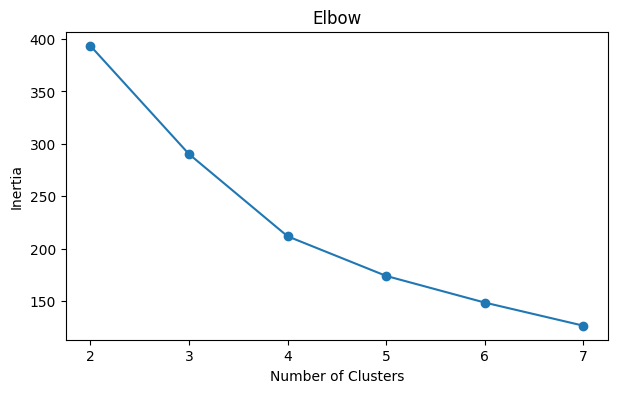

In [204]:
plt.figure(figsize=(7,4))

plt.plot(
    range(2,8),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow")

plt.show()

Here I choose 4 clusters as the optimal number of clusters for the analysis

### Final clusters

Here I choose 4 clusters for the final cluster analysis

In [205]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

successful_master["Cluster"] = kmeans.fit_predict(X_scaled)

### Viewing stats of each Cluster

In [206]:
successful_master["Cluster"].value_counts().sort_index()

Cluster
0    32
1    32
2    16
3    28
Name: count, dtype: int64

### Summary statistics of each feature of the clusters

In [207]:
cluster_profile = (
    successful_master
    .groupby("Cluster")[cluster_features]
    .mean()
    .round(2)
)

cluster_profile

,Population,GDP_Per_Capita,Media_Literacy_Index,Governance,Social_Capital,Personal_Freedom,Education
Cluster,,,,,,,
0,11938699.75,16447.33,40.88,57.32,56.23,71.84,75.50
1,8121344.75,62095.27,65.62,85.39,72.37,89.94,84.84
2,64391715.75,37389.01,55.75,74.11,64.20,82.21,81.42
3,4223026.00,23180.14,56.86,70.89,59.95,81.91,80.54


### Box plots of variance between Signatures Per Capita across different Clusters

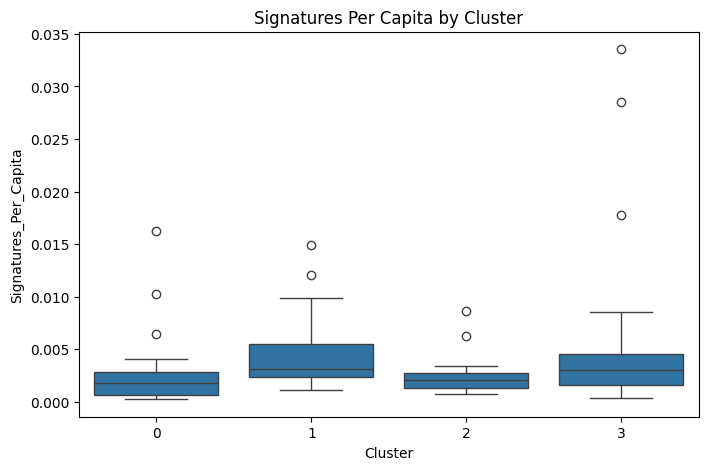

In [208]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=successful_master,
    x="Cluster",
    y="Signatures_Per_Capita"
)

plt.title("Signatures Per Capita by Cluster")
plt.show()

### Box plots of variance between Log Signatures Per Capita across different Clusters

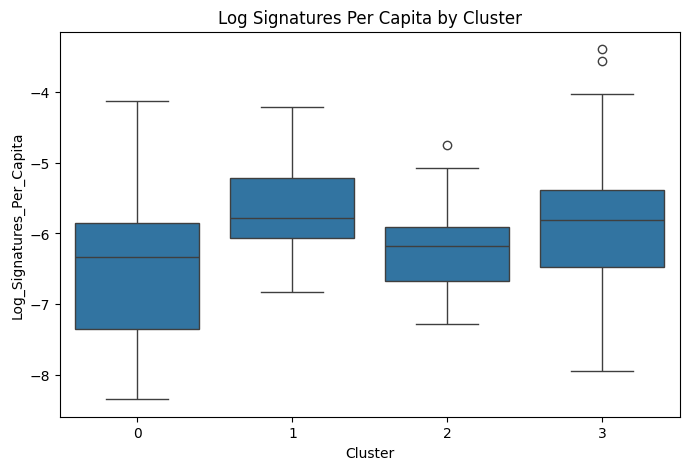

In [209]:
successful_master["Log_Signatures_Per_Capita"] = np.log(
    successful_master["Signatures_Per_Capita"]
)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=successful_master,
    x="Cluster",
    y="Log_Signatures_Per_Capita"
)

plt.title("Log Signatures Per Capita by Cluster")
plt.show()

### Creating a Map to show each cluster

In [216]:
cluster_map = successful_master[
    ["Country", "Cluster"]
].drop_duplicates()

In [211]:
cluster_map.head()

,Country,Cluster
0,Austria,1
1,Belgium,1
2,Bulgaria,0
3,Croatia,0
4,Cyprus,0


### Cluster Map

In [212]:
# https://www.datacamp.com/tutorial/making-map-in-python-using-plotly-library-guide

fig = px.choropleth(
    cluster_map,
    locations="Country",
    locationmode="country names",
    color="Cluster",
    projection="natural earth",
    title="European Countries by Cluster"
)

fig.update_geos(
    center={"lat": 48, "lon": 15},
    lataxis_range=[33, 70],   
    lonaxis_range=[-12, 35]  
)

fig.update_layout(
    width=1000,
    height=700,
    margin={"r":0, "t":40, "l":0, "b":0}
)

fig.show()


C:\Users\Matty\AppData\Local\Temp\ipykernel_21288\2018450132.py:3: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



### PCA selected scaled variables

In [213]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

### Two components for X and Y axis in PLots

In [214]:
pca_cluster = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": successful_master["Cluster"]
})

### Plot of Clusters against PCA1 and PCA2

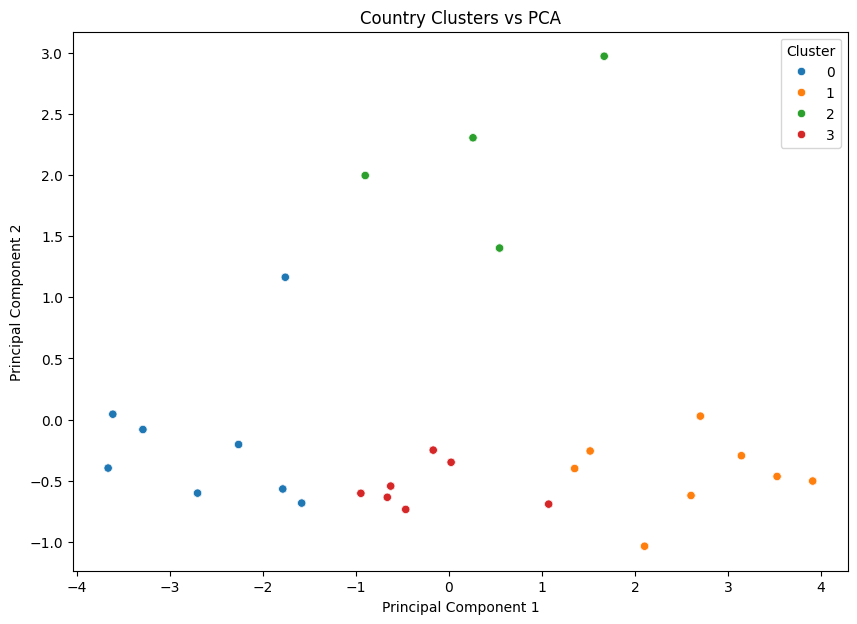

In [217]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_cluster,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10"
)

plt.title("Country Clusters vs PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()